In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Understanding the data
This cell opens the json file as a DataFrame in Pandas. Then, we print the shape of the DataFrame which shows 24016 rows and 15 columns. The final line of code prints an overview of each column, showing the first and last 5 rows with column names.

In [2]:
df = pd.read_json("data/istanbul_housing.json")
print(df.shape)
df.info

(24016, 15)


<bound method DataFrame.info of                                                   Başlık          Fiyat  \
0      ▃۩ADA'dan۩▃TEK YETKİLİ▃MİNİBÜSE YAKIN▃GENÇ BİN...   5.390.000 TL   
1      HACIALİOĞLU'NDAN PRAVA KARTALDA ÖN CEPHE BALKO...   5.690.000 TL   
2      SIFIR İNŞAATTA 3+1 TEK DAİRE ÜZERİ 3 CEPHESİ A...   1.850.000 TL   
3      KELEPİR 2+1  İÇİ YAPILI ÇİFT CEPHE MERKEZİ KON...     895.000 TL   
4      BEYLİKDÜZÜ ASRİVA'DAN BUTİK SİTE İÇİ EMSALLERİ...   3.250.000 TL   
...                                                  ...            ...   
24011  ŞİRİNEVLER MERKEZ'DE 13 YILLIK SATILIK 3.KAT 1...   2.650.000 TL   
24012  Azizoğlu GAYRİMENKULDEN SELAMİ ALİ MAHLESINDE ...   4.050.000 TL   
24013  BLUECORNERDAN ERENKÖYDE MARMARAYA YAKIN 3+1 15...  17.000.000 TL   
24014  BÜYÜKÇEKMECEDE MERKEZİ KONUMDA DENİZE KOMŞU SI...   3.990.000 TL   
24015             SUR YAPI MİRAGE PROJESİNDE SATILIK 3+1   8.250.000 TL   

      Oda + Salon Sayısı Brüt / Net M2 Bulunduğu Kat   Bina Yaşı  \

#### The first 5 rows of the data frame.

In [3]:
df.head()

,Başlık,Fiyat,Oda + Salon Sayısı,Brüt / Net M2,Bulunduğu Kat,Bina Yaşı,Isınma Tipi,Kat Sayısı,Eşya Durumu,Banyo Sayısı,Kullanım Durumu,Tapu Durumu,İlçe,Mahalle,Link
0,▃۩ADA'dan۩▃TEK YETKİLİ▃MİNİBÜSE YAKIN▃GENÇ BİN...,5.390.000 TL,2 + 1,85 m2,Bahçe Katı,5 Yaşında,Merkezi,4 Katlı,Eşyalı Değil,1.0,Boş,Kat Mülkiyeti,Maltepe,Altıntepe,https://www.hepsiemlak.com/istanbul-maltepe-al...
1,HACIALİOĞLU'NDAN PRAVA KARTALDA ÖN CEPHE BALKO...,5.690.000 TL,1 + 1,65 m2,3. Kat,4 Yaşında,Merkezi (Pay Ölçer),26 Katlı,Eşyalı Değil,1.0,Boş,Kat Mülkiyeti,Kartal,Orhantepe,https://www.hepsiemlak.com/istanbul-kartal-orh...
2,SIFIR İNŞAATTA 3+1 TEK DAİRE ÜZERİ 3 CEPHESİ A...,1.850.000 TL,3 + 1,112 m2,2. Kat,Sıfır Bina,Kombi,5 Katlı,Eşyalı Değil,1.0,Boş,Kat Mülkiyeti,Esenyurt,Çınar,https://www.hepsiemlak.com/istanbul-esenyurt-c...
3,KELEPİR 2+1 İÇİ YAPILI ÇİFT CEPHE MERKEZİ KON...,895.000 TL,2 + 1,104 m2,Bahçe Katı,5 Yaşında,Kombi,4 Katlı,Eşyalı Değil,1.0,Boş,Kat Mülkiyeti,Esenyurt,Yeşilkent,https://www.hepsiemlak.com/istanbul-esenyurt-y...
4,BEYLİKDÜZÜ ASRİVA'DAN BUTİK SİTE İÇİ EMSALLERİ...,3.250.000 TL,3 + 1,170 m2,2. Kat,Sıfır Bina,Kombi,4 Katlı,Eşyalı Değil,2.0,Boş,Tapu Yok,Beylikdüzü,Adnan Kahveci,https://www.hepsiemlak.com/istanbul-beylikduzu...


#### Checking the values and their types

In [7]:
prices = df['Fiyat']
print(f"As a Pandas Series object:\n{prices}\nObject type: {type(prices)}")

As a Pandas Series object:
0         5.390.000 TL
1         5.690.000 TL
2         1.850.000 TL
3           895.000 TL
4         3.250.000 TL
             ...      
24011     2.650.000 TL
24012     4.050.000 TL
24013    17.000.000 TL
24014     3.990.000 TL
24015     8.250.000 TL
Name: Fiyat, Length: 24016, dtype: str
Object type: <class 'pandas.Series'>


In [8]:
first_price = df['Fiyat'][0]
print(f"The type of the price is {type(first_price)}")

The type of the price is <class 'str'>


In [10]:
prices_nparray = df['Fiyat'].to_numpy()
print(f"As a numpy array:\n{prices_nparray}\nObject type: {type(prices_nparray)}")

As a numpy array:
['5.390.000 TL' '5.690.000 TL' '1.850.000 TL' ... '17.000.000 TL'
 '3.990.000 TL' '8.250.000 TL']
Object type: <class 'numpy.ndarray'>


In [11]:
titles = df['Başlık']
first_title = df['Başlık'][0]
print(f"The type of the title is {type(first_title)}")

The type of the title is <class 'str'>


## Modifying the DataFrame for easier manipulation
#### Removing unnecessary colums and some other fixes
This code removes the columns called Başlık, Kullanım Durumu, Link, Isınma Tipi and Tapu Durumu. It then changes the naming of a column to match what is actually included in it. It also breaks the column Oda + Salon Sayısı into two separate columns. 
Then, it prints the renewed data.

In [12]:
df = df.drop(columns=["Başlık", "Kullanım Durumu", "Link", "Tapu Durumu", "Isınma Tipi"])
df = df.rename(columns={"Brüt / Net M2": "Brüt M2"}) # I only scraped the brute size.
df.head()

,Fiyat,Oda + Salon Sayısı,Brüt M2,Bulunduğu Kat,Bina Yaşı,Kat Sayısı,Eşya Durumu,Banyo Sayısı,İlçe,Mahalle
0,5.390.000 TL,2 + 1,85 m2,Bahçe Katı,5 Yaşında,4 Katlı,Eşyalı Değil,1.0,Maltepe,Altıntepe
1,5.690.000 TL,1 + 1,65 m2,3. Kat,4 Yaşında,26 Katlı,Eşyalı Değil,1.0,Kartal,Orhantepe
2,1.850.000 TL,3 + 1,112 m2,2. Kat,Sıfır Bina,5 Katlı,Eşyalı Değil,1.0,Esenyurt,Çınar
3,895.000 TL,2 + 1,104 m2,Bahçe Katı,5 Yaşında,4 Katlı,Eşyalı Değil,1.0,Esenyurt,Yeşilkent
4,3.250.000 TL,3 + 1,170 m2,2. Kat,Sıfır Bina,4 Katlı,Eşyalı Değil,2.0,Beylikdüzü,Adnan Kahveci


In [14]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 24016 entries, 0 to 24015
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Fiyat               24016 non-null  str    
 1   Oda + Salon Sayısı  24016 non-null  str    
 2   Brüt M2             24016 non-null  str    
 3   Bulunduğu Kat       24012 non-null  str    
 4   Bina Yaşı           24016 non-null  str    
 5   Kat Sayısı          24015 non-null  str    
 6   Eşya Durumu         22320 non-null  str    
 7   Banyo Sayısı        23890 non-null  float64
 8   İlçe                24016 non-null  str    
 9   Mahalle             24016 non-null  str    
dtypes: float64(1), str(9)
memory usage: 1.8 MB


#### Clean the price and turn into a float
Starting with the prices, we get rid of elements such as TL, dots and empty spaces. Then, we turn the entire column to be of type float. We display the new table.

In [6]:
df["Fiyat"]= df["Fiyat"].str.replace("TL", "")
df["Fiyat"]= df["Fiyat"].str.replace(".", "")
df["Fiyat"]= df["Fiyat"].str.strip()
df["Fiyat"]= df["Fiyat"].astype(float)

df.head()

,Fiyat,Oda + Salon Sayısı,Brüt M2,Bulunduğu Kat,Bina Yaşı,Kat Sayısı,Eşya Durumu,Banyo Sayısı,İlçe,Mahalle
0,5390000.0,2 + 1,85 m2,Bahçe Katı,5 Yaşında,4 Katlı,Eşyalı Değil,1.0,Maltepe,Altıntepe
1,5690000.0,1 + 1,65 m2,3. Kat,4 Yaşında,26 Katlı,Eşyalı Değil,1.0,Kartal,Orhantepe
2,1850000.0,3 + 1,112 m2,2. Kat,Sıfır Bina,5 Katlı,Eşyalı Değil,1.0,Esenyurt,Çınar
3,895000.0,2 + 1,104 m2,Bahçe Katı,5 Yaşında,4 Katlı,Eşyalı Değil,1.0,Esenyurt,Yeşilkent
4,3250000.0,3 + 1,170 m2,2. Kat,Sıfır Bina,4 Katlı,Eşyalı Değil,2.0,Beylikdüzü,Adnan Kahveci


#### Cleaning the number of rooms
Finding all unique values for the number of rooms and living rooms. Finding the value count for each unique value. If the value count for a value is below 5, delete the entire row.

In [7]:
print(f"Before cleaning the outliers: {df["Oda + Salon Sayısı"].unique()}")
value_counts = df['Oda + Salon Sayısı'].value_counts()
room_outliers = value_counts[value_counts < 5].index
df = df[~df["Oda + Salon Sayısı"].isin(room_outliers)]
print(f"After cleaning the outliers: {df["Oda + Salon Sayısı"].unique()}")

Before cleaning the outliers: ['2 + 1' '1 + 1' '3 + 1' '4 + 1' '3 + 2' '5 + 2' '6 + 2' '5 + 1' '1 + 4'
 '6 + 1' '2 + 0' '8 + 2' '4 + 2' '1 + 0' '3 + 0' '2 + 2' '160 + 120'
 '5 + 0' '7 + 1' '4 + 4' '31 + 12' '11 + 1' '3 + 8' '2 + 13' '5 + 3'
 '2 + 3' '4 + 0' '3 + 3' '1 + 2' '9 + 1' '312 + 1' '25 + 12' '7 + 2'
 '3 + 133' '7 + 3' '10 + 0' '2 + 5' '8 + 1' '3 + 11' '1 + 11' '6 + 3'
 '2 + 11' '14 + 4' '9 + 2' '6 + 4' '1 + 3' '4 + 3' '3 + 4' '10 + 4'
 '31 + 1' '2 + 4' '2 + 22' '80 + 70' '33 + 1' '2 + 12' '9 + 3']
After cleaning the outliers: ['2 + 1' '1 + 1' '3 + 1' '4 + 1' '3 + 2' '5 + 2' '6 + 2' '5 + 1' '6 + 1'
 '2 + 0' '8 + 2' '4 + 2' '1 + 0' '3 + 0' '2 + 2' '7 + 1' '5 + 3' '4 + 0'
 '3 + 3' '1 + 2' '7 + 2' '6 + 3']


### Separating the column into two as room number and living room number
Split the Oda + Salon Sayısı values with a regular expression. Assign first part to a new column called Oda and the second part into a new column called Salon.

In [8]:
df[['Oda', 'Salon']] = df['Oda + Salon Sayısı'].str.split(r'\s*\+\s*', expand=True).astype(int)
df = df.drop(columns ='Oda + Salon Sayısı')
df.head()

,Fiyat,Brüt M2,Bulunduğu Kat,Bina Yaşı,Kat Sayısı,Eşya Durumu,Banyo Sayısı,İlçe,Mahalle,Oda,Salon
0,5390000.0,85 m2,Bahçe Katı,5 Yaşında,4 Katlı,Eşyalı Değil,1.0,Maltepe,Altıntepe,2,1
1,5690000.0,65 m2,3. Kat,4 Yaşında,26 Katlı,Eşyalı Değil,1.0,Kartal,Orhantepe,1,1
2,1850000.0,112 m2,2. Kat,Sıfır Bina,5 Katlı,Eşyalı Değil,1.0,Esenyurt,Çınar,3,1
3,895000.0,104 m2,Bahçe Katı,5 Yaşında,4 Katlı,Eşyalı Değil,1.0,Esenyurt,Yeşilkent,2,1
4,3250000.0,170 m2,2. Kat,Sıfır Bina,4 Katlı,Eşyalı Değil,2.0,Beylikdüzü,Adnan Kahveci,3,1


#### Cleaning the square meter column
Delete the strings and empty spaces. Turn the values into floats.

In [9]:
value = df["Brüt M2"][0]
print(type(value))
df.head()

<class 'str'>


,Fiyat,Brüt M2,Bulunduğu Kat,Bina Yaşı,Kat Sayısı,Eşya Durumu,Banyo Sayısı,İlçe,Mahalle,Oda,Salon
0,5390000.0,85 m2,Bahçe Katı,5 Yaşında,4 Katlı,Eşyalı Değil,1.0,Maltepe,Altıntepe,2,1
1,5690000.0,65 m2,3. Kat,4 Yaşında,26 Katlı,Eşyalı Değil,1.0,Kartal,Orhantepe,1,1
2,1850000.0,112 m2,2. Kat,Sıfır Bina,5 Katlı,Eşyalı Değil,1.0,Esenyurt,Çınar,3,1
3,895000.0,104 m2,Bahçe Katı,5 Yaşında,4 Katlı,Eşyalı Değil,1.0,Esenyurt,Yeşilkent,2,1
4,3250000.0,170 m2,2. Kat,Sıfır Bina,4 Katlı,Eşyalı Değil,2.0,Beylikdüzü,Adnan Kahveci,3,1


In [10]:
df["Brüt M2"] = df["Brüt M2"].str.replace(" m2", "")
df["Brüt M2"] = df["Brüt M2"].str.strip()
df["Brüt M2"] = df["Brüt M2"].astype(float)
unique_sorted_values = np.sort(df["Brüt M2"].unique())
print(unique_sorted_values)

[  1.      1.055   1.11    1.2     9.     15.     20.     21.     25.
  28.     29.     30.     33.     35.     37.     38.     39.     40.
  41.     42.     43.     44.     45.     47.     48.     49.     50.
  51.     52.     53.     54.     55.     56.     57.     58.     59.
  60.     61.     62.     63.     64.     65.     66.     67.     68.
  69.     70.     71.     72.     73.     74.     75.     76.     77.
  78.     79.     80.     81.     82.     83.     84.     85.     86.
  87.     88.     89.     90.     91.     92.     93.     94.     95.
  96.     97.     98.     99.    100.    101.    102.    103.    104.
 105.    106.    107.    108.    109.    110.    111.    112.    113.
 114.    115.    116.    117.    118.    119.    120.    121.    122.
 123.    124.    125.    126.    127.    128.    129.    130.    131.
 132.    133.    134.    135.    136.    137.    138.    139.    140.
 141.    142.    143.    144.    145.    146.    147.    148.    149.
 150.    150.12  151

#### Turn the building ages into numeric values
When we print all values for the age of the building, we see that they either say "Sıfır Bina" or "__ Yaşında".
If the value is Sıfır Bina, we change it to 0. In all other cases, we remove the " Yaşında" and keep the integer value. We print the renewed values sorted to see any outlier cases.

In [11]:
print(f"Ages before cleaning: {df['Bina Yaşı'].unique()}")
df.loc[df["Bina Yaşı"] == "Sıfır Bina", "Bina Yaşı"] = 0
df.loc[df["Bina Yaşı"] != 0, "Bina Yaşı"] = df.loc[df["Bina Yaşı"] != 0, "Bina Yaşı"].str.replace(" Yaşında", "").astype(int)
building_ages = df["Bina Yaşı"].unique()
print(f"Sorted ages after cleaning: {np.sort(building_ages)}")

Ages before cleaning: ['5 Yaşında' '4 Yaşında' 'Sıfır Bina' '1 Yaşında' '8 Yaşında' '2 Yaşında'
 '7 Yaşında' '10 Yaşında' '3 Yaşında' '6 Yaşında' '30 Yaşında'
 '26 Yaşında' '11 Yaşında' '35 Yaşında' '23 Yaşında' '21 Yaşında'
 '13 Yaşında' '55 Yaşında' '24 Yaşında' '15 Yaşında' '20 Yaşında'
 '29 Yaşında' '31 Yaşında' '16 Yaşında' '45 Yaşında' '25 Yaşında'
 '28 Yaşında' '18 Yaşında' '17 Yaşında' '27 Yaşında' '36 Yaşında'
 '40 Yaşında' '80 Yaşında' '49 Yaşında' '14 Yaşında' '34 Yaşında'
 '340 Yaşında' '33 Yaşında' '12 Yaşında' '50 Yaşında' '38 Yaşında'
 '9 Yaşında' '32 Yaşında' '19 Yaşında' '44 Yaşında' '37 Yaşında'
 '22 Yaşında' '100 Yaşında' '42 Yaşında' '59 Yaşında' '60 Yaşında'
 '70 Yaşında' '48 Yaşında' '54 Yaşında' '65 Yaşında' '52 Yaşında'
 '39 Yaşında' '51 Yaşında' '53 Yaşında' '47 Yaşında' '68 Yaşında'
 '56 Yaşında' '43 Yaşında' '46 Yaşında' '223 Yaşında' '141 Yaşında'
 '110 Yaşında' '330 Yaşında' '64 Yaşında' '75 Yaşında' '41 Yaşında'
 '123 Yaşında' '200 Yaşında' '89 Yaşında' '2

#### District check
Check that the names of districts are correct and that each district represented in the data.

In [12]:
print(df["İlçe"].unique())
print(df["İlçe"].nunique())

['Maltepe' 'Kartal' 'Esenyurt' 'Beylikdüzü' 'Kadıköy' 'Şişli' 'Başakşehir'
 'Arnavutköy' 'Bayrampaşa' 'Gaziosmanpaşa' 'Bahçelievler' 'Fatih' 'Beykoz'
 'Beşiktaş' 'Adalar' 'Tuzla' 'Üsküdar' 'Avcılar' 'Küçükçekmece'
 'Eyüpsultan' 'Zeytinburnu' 'Sultangazi' 'Çekmeköy' 'Sarıyer' 'Sancaktepe'
 'Bakırköy' 'Ataşehir' 'Silivri' 'Pendik' 'Çatalca' 'Güngören' 'Kağıthane'
 'Beyoğlu' 'Sultanbeyli' 'Ümraniye' 'Bağcılar' 'Büyükçekmece' 'Esenler'
 'Şile']
39


#### Cleaning the column for number of floors (in the building)


In [13]:
number_floor = df['Kat Sayısı'].str.replace(' Katlı', '', regex=False).str.strip()
number_floor = pd.to_numeric(number_floor, errors='coerce').fillna(-1)
df['Kat Sayısı'] = number_floor.astype(int)

print(df["Kat Sayısı"].unique())

[  4  26   5  10   3  19   6  18   9   7  12  15   8   2  17  13  11  30
  20  14   1  37  50  24  45  21  27  33  22  35  16  31  25  28  40  23
 520  36  29  46  34  42  32  -1  39  38  48  60 318  43 620  44 119  47
  52  64  62  51 253  55 221  54]


Turn number of bathrooms from floats to integer values.

In [14]:
df["Banyo Sayısı"] = pd.to_numeric(df["Banyo Sayısı"], errors='coerce').fillna(-1).astype(int)
print(df["Banyo Sayısı"].unique())

[ 1  2  3  4  6 -1  5  7 11 15 33]


In [15]:
print(df['Eşya Durumu'].unique())
none_count = df["Eşya Durumu"].isna().sum()
print(none_count)
df['Eşya Durumu'] = np.where(df['Eşya Durumu'] == "Eşyalı", True, False)
print(df['Eşya Durumu'].unique())

['Eşyalı Değil' 'Eşyalı' None]
1689
[False  True]


In [16]:
print(df['Bulunduğu Kat'].unique())

['Bahçe Katı' '3. Kat' '2. Kat' 'Giriş Katı' '6. Kat' '7. Kat' '8. Kat'
 'Ara Kat' 'Teras Katı' '1. Kat' '4. Kat' 'Villa Katı' '12. Kat'
 'Yüksek Giriş' '5. Kat' '10. Kat' 'En Üst Kat' '11. Kat' '21 ve üzeri'
 '9. Kat' 'Kot 2' '19. Kat' '13. Kat' 'Yarı Bodrum' 'Çatı Katı' '16. Kat'
 'Zemin' '14. Kat' 'Kot 1' 'Bodrum ve Zemin' 'Bodrum' '15. Kat' '20. Kat'
 'Kot 3' '18. Kat' '17. Kat' None]


In [17]:
df.head()

,Fiyat,Brüt M2,Bulunduğu Kat,Bina Yaşı,Kat Sayısı,Eşya Durumu,Banyo Sayısı,İlçe,Mahalle,Oda,Salon
0,5390000.0,85.0,Bahçe Katı,5,4,False,1,Maltepe,Altıntepe,2,1
1,5690000.0,65.0,3. Kat,4,26,False,1,Kartal,Orhantepe,1,1
2,1850000.0,112.0,2. Kat,0,5,False,1,Esenyurt,Çınar,3,1
3,895000.0,104.0,Bahçe Katı,5,4,False,1,Esenyurt,Yeşilkent,2,1
4,3250000.0,170.0,2. Kat,0,4,False,2,Beylikdüzü,Adnan Kahveci,3,1


## Plotting the data and managing the outliers
Find the range for the price.

In [18]:
min_price = df["Fiyat"].min()
max_price = df["Fiyat"].max()
print(min_price)
print(max_price)

sorted_prices = df['Fiyat'].sort_values()
sorted_prices.to_csv('sorted_prices.csv', index=False)

1.0
4950000000.0


Plot the price with outliers.

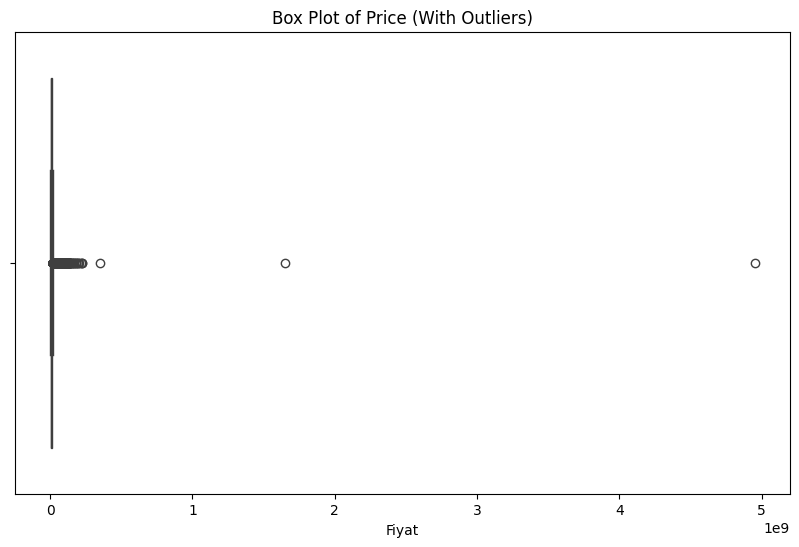

In [19]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='Fiyat')
plt.title('Box Plot of Price (With Outliers)')
plt.show()

Find the interquartile range and remove the outliers outside of the range.
Keep the updated price information in a separate variable.
The regular interquartile range did not work on the prices. There are prices which are too low and the highest price is not high enough.

In [20]:
Q1 = df['Fiyat'].quantile(0.25)
Q3 = df['Fiyat'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

filtered_data_iqr = df[(df['Fiyat'] >= lower_bound) & (df['Fiyat'] <= upper_bound)]

print(filtered_data_iqr["Fiyat"].sort_values())

15421           1.0
10670        1250.0
18344        1500.0
16074        1500.0
23596        2250.0
            ...    
8101     21500000.0
8100     21500000.0
13623    21500000.0
15269    21500000.0
10577    21500000.0
Name: Fiyat, Length: 21892, dtype: float64


In [21]:
min_price_threshold = 300000 
max_price_threshold = 200000000  

filtered_data = df[(df['Fiyat'] >= min_price_threshold) & (df['Fiyat'] <= max_price_threshold)]

print(f"Filtered data range: {filtered_data['Fiyat'].min()} - {filtered_data['Fiyat'].max()}")

mean_price = filtered_data["Fiyat"].mean()
median_price = filtered_data["Fiyat"].median()
std_price = filtered_data["Fiyat"].std()

print(f"Mean:{mean_price.astype(int)} Median: {median_price.astype(int)} Std: {std_price.astype(int)}")

Filtered data range: 320000.0 - 200000000.0
Mean:9249279 Median: 5450000 Std: 11826099


The IQR clean-up gets rid of the skewedness of the original data while the manual threshold method still keeps it. This is due to the fact that in İstanbul, it is less likely to find underpriced apartments and more common to find overpriced, luxury apartments.

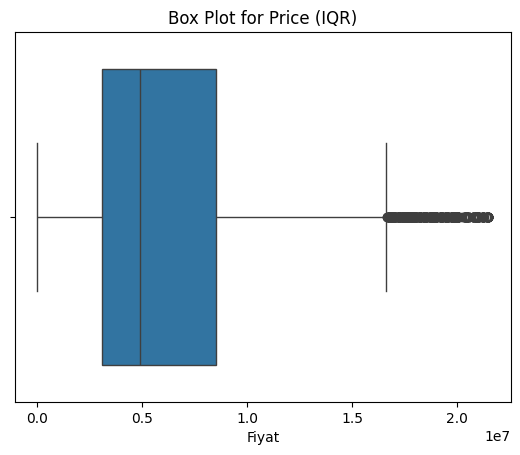

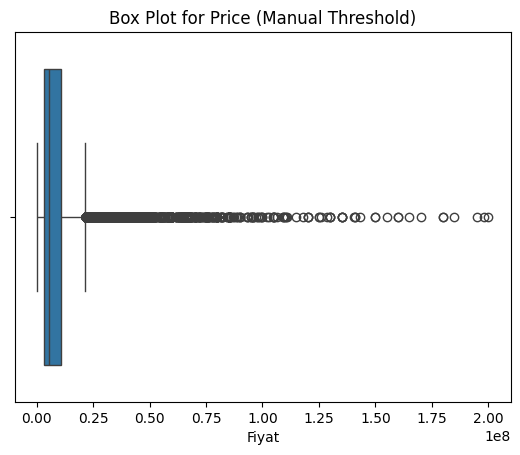

In [22]:
sns.boxplot(data=filtered_data_iqr, x='Fiyat')
plt.title('Box Plot for Price (IQR)')
plt.show()

sns.boxplot(data=filtered_data, x='Fiyat')
plt.title('Box Plot for Price (Manual Threshold)')
plt.show()

In [23]:
filtered_data.head()

,Fiyat,Brüt M2,Bulunduğu Kat,Bina Yaşı,Kat Sayısı,Eşya Durumu,Banyo Sayısı,İlçe,Mahalle,Oda,Salon
0,5390000.0,85.0,Bahçe Katı,5,4,False,1,Maltepe,Altıntepe,2,1
1,5690000.0,65.0,3. Kat,4,26,False,1,Kartal,Orhantepe,1,1
2,1850000.0,112.0,2. Kat,0,5,False,1,Esenyurt,Çınar,3,1
3,895000.0,104.0,Bahçe Katı,5,4,False,1,Esenyurt,Yeşilkent,2,1
4,3250000.0,170.0,2. Kat,0,4,False,2,Beylikdüzü,Adnan Kahveci,3,1


#### List of districts from the highest priced to lowest priced

In [24]:
district_stats = filtered_data.groupby('İlçe')['Fiyat'].agg(['mean', 'median', 'std'])
districts_sorted = district_stats.sort_values(by='mean', ascending=False)
districts_sorted = districts_sorted.round(2)
print(districts_sorted)

                      mean      median          std
İlçe                                               
Beşiktaş       25732266.43  15000000.0  29891400.53
Sarıyer        20189456.29  15300000.0  18469143.84
Bakırköy       19778740.94  16000000.0  14528499.81
Kadıköy        18157308.07  14850000.0  12953453.06
Beykoz         15382882.88  11300000.0  12650918.93
Üsküdar        10855150.46   7500000.0  10387062.53
Adalar         10689090.91   9600000.0   5191773.47
Beyoğlu        10256378.88   7200000.0   9808776.41
Şişli           9823885.48   5900000.0  12858456.62
Eyüpsultan      8894144.33   5547500.0   9077819.91
Zeytinburnu     8084851.21   4500000.0  11166925.39
Ataşehir        7869701.61   6000000.0   6508661.61
Başakşehir      7374253.26   5500000.0   5441779.86
Maltepe         7336558.42   6400000.0   3930614.33
Çatalca         7291666.67   3825000.0   9426155.99
Kartal          6265252.10   5400000.0   3475092.34
Ümraniye        6147533.96   4900000.0   3971253.95
Pendik      

Cleanin the houses which are under 15 m2 and plotting the results. 

In [25]:
filtered_data = filtered_data[(filtered_data['Brüt M2'] >= 15) & (filtered_data['Brüt M2'] <= 600)]
print(np.sort(filtered_data["Brüt M2"].unique()))

[ 15.    20.    21.    25.    28.    29.    30.    33.    35.    37.
  38.    39.    40.    41.    42.    43.    44.    45.    47.    48.
  49.    50.    51.    52.    53.    54.    55.    56.    57.    58.
  59.    60.    61.    62.    63.    64.    65.    66.    67.    68.
  69.    70.    71.    72.    73.    74.    75.    76.    77.    78.
  79.    80.    81.    82.    83.    84.    85.    86.    87.    88.
  89.    90.    91.    92.    93.    94.    95.    96.    97.    98.
  99.   100.   101.   102.   103.   104.   105.   106.   107.   108.
 109.   110.   111.   112.   113.   114.   115.   116.   117.   118.
 119.   120.   121.   122.   123.   124.   125.   126.   127.   128.
 129.   130.   131.   132.   133.   134.   135.   136.   137.   138.
 139.   140.   141.   142.   143.   144.   145.   146.   147.   148.
 149.   150.   150.12 151.   152.   153.   154.   155.   156.   157.
 158.   159.   160.   161.   162.   163.   164.   165.   166.   167.
 168.   169.   170.   171.   172. 

<Axes: xlabel='Brüt M2'>

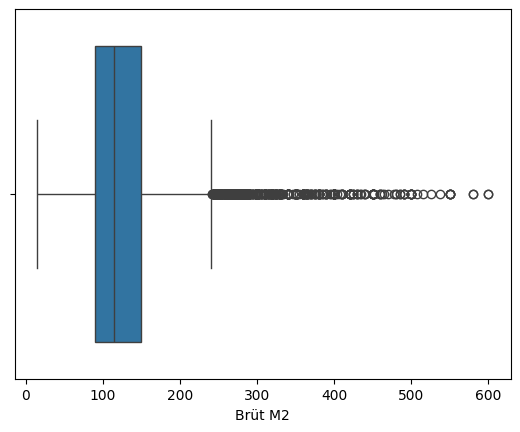

In [26]:
sns.boxplot(data=filtered_data, x='Brüt M2')

Clean outliers for number of floors with manual thresholds. 

In [27]:
print(np.sort(filtered_data["Kat Sayısı"].unique()))

filtered_data = filtered_data[filtered_data['Kat Sayısı'].between(1, 60, inclusive='right')] 

print(np.sort(filtered_data["Kat Sayısı"].unique()))

[ -1   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17
  18  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35
  36  37  38  39  40  42  43  44  45  46  47  48  50  51  52  54  55  60
  62  64 119 221 253 318 520 620]
[ 2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25
 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 42 43 44 45 46 47 48 50 51
 52 54 55 60]


Get rid of None values for the floor of the apartment. 

In [28]:
print(filtered_data["Bulunduğu Kat"].unique())
filtered_data.dropna(subset=['Bulunduğu Kat'], inplace=True)
filtered_data = filtered_data[filtered_data['Bulunduğu Kat'] != 'None']
print(filtered_data["Bulunduğu Kat"].unique())

['Bahçe Katı' '3. Kat' '2. Kat' 'Giriş Katı' '6. Kat' '7. Kat' '8. Kat'
 'Ara Kat' 'Teras Katı' '1. Kat' '4. Kat' 'Villa Katı' '12. Kat'
 'Yüksek Giriş' '5. Kat' '10. Kat' 'En Üst Kat' '11. Kat' '21 ve üzeri'
 '9. Kat' 'Kot 2' '19. Kat' '13. Kat' 'Yarı Bodrum' 'Çatı Katı' '16. Kat'
 'Zemin' '14. Kat' 'Kot 1' 'Bodrum ve Zemin' 'Bodrum' '15. Kat' '20. Kat'
 'Kot 3' '18. Kat' '17. Kat' None]
['Bahçe Katı' '3. Kat' '2. Kat' 'Giriş Katı' '6. Kat' '7. Kat' '8. Kat'
 'Ara Kat' 'Teras Katı' '1. Kat' '4. Kat' 'Villa Katı' '12. Kat'
 'Yüksek Giriş' '5. Kat' '10. Kat' 'En Üst Kat' '11. Kat' '21 ve üzeri'
 '9. Kat' 'Kot 2' '19. Kat' '13. Kat' 'Yarı Bodrum' 'Çatı Katı' '16. Kat'
 'Zemin' '14. Kat' 'Kot 1' 'Bodrum ve Zemin' 'Bodrum' '15. Kat' '20. Kat'
 'Kot 3' '18. Kat' '17. Kat']


Get rid of the Kot information for floors.

In [29]:
mask = filtered_data['Bulunduğu Kat'].str.startswith('Kot ')
filtered_data.loc[mask, 'Bulunduğu Kat'] = filtered_data.loc[mask, 'Bulunduğu Kat'].str.replace('Kot ', '', regex=False)
print(filtered_data["Bulunduğu Kat"].unique())

['Bahçe Katı' '3. Kat' '2. Kat' 'Giriş Katı' '6. Kat' '7. Kat' '8. Kat'
 'Ara Kat' 'Teras Katı' '1. Kat' '4. Kat' 'Villa Katı' '12. Kat'
 'Yüksek Giriş' '5. Kat' '10. Kat' 'En Üst Kat' '11. Kat' '21 ve üzeri'
 '9. Kat' '2' '19. Kat' '13. Kat' 'Yarı Bodrum' 'Çatı Katı' '16. Kat'
 'Zemin' '14. Kat' '1' 'Bodrum ve Zemin' 'Bodrum' '15. Kat' '20. Kat' '3'
 '18. Kat' '17. Kat']


Replace string floor types with numerical values.

In [30]:
filtered_data['Bulunduğu Kat'] = filtered_data['Bulunduğu Kat'].str.replace(r"\. Kat","", regex=True)
floor_mapping = {'Bodrum Kat': -3, 'Bodrum': -3, 'Yarı Bodrum': -2, 'Bahçe Katı': -1, 'Giriş Katı': 0, 'Zemin': 0, 'Yüksek Giriş': 0.5, 
                 'Bodrum ve Zemin': -2} 

filtered_data['Bulunduğu Kat'] = filtered_data['Bulunduğu Kat'].replace(floor_mapping).astype(str)

print(filtered_data["Bulunduğu Kat"].unique())

['-1' '3' '2' '0' '6' '7' '8' 'Ara Kat' 'Teras Katı' '1' '4' 'Villa Katı'
 '12' '0.5' '5' '10' 'En Üst Kat' '11' '21 ve üzeri' '9' '19' '13' '-2'
 'Çatı Katı' '16' '14' '-3' '15' '20' '18' '17']


Remove the type Villa Katı and manage the highest floors.

In [31]:
filtered_data = filtered_data[filtered_data['Bulunduğu Kat'] != 'Villa Katı']

filtered_data.loc[
    (filtered_data['Bulunduğu Kat'] == 'En Üst Kat') | 
    (filtered_data['Bulunduğu Kat'] == 'Çatı Katı') | 
    (filtered_data['Bulunduğu Kat'] == 'Teras Katı'), 
    'Bulunduğu Kat'] = filtered_data['Kat Sayısı']
print(filtered_data["Bulunduğu Kat"].unique())

['-1' '3' '2' '0' '6' '7' '8' 'Ara Kat' 4 '1' '4' '12' '0.5' '5' '10' '11'
 '21 ve üzeri' '9' '19' '13' '-2' 5 3 8 7 '16' '14' 6 '-3' 20 '15' '20' 2
 11 '18' '17' 14 9 13 10 23 18 12 33 30]


Manage the ambigous type '21 ve üzeri' according to the number of floors in the building.

In [32]:
print(filtered_data.loc[filtered_data['Bulunduğu Kat'] == '21 ve üzeri', 'Kat Sayısı'].unique())
print(filtered_data["Bulunduğu Kat"].unique())

[30 37 45 35 31 33 50 23 36 27 29 46 28 34 24 32 22 26 39 48 42 44 47 40
 25]
['-1' '3' '2' '0' '6' '7' '8' 'Ara Kat' 4 '1' '4' '12' '0.5' '5' '10' '11'
 '21 ve üzeri' '9' '19' '13' '-2' 5 3 8 7 '16' '14' 6 '-3' 20 '15' '20' 2
 11 '18' '17' 14 9 13 10 23 18 12 33 30]


In [33]:
filtered_data.loc[filtered_data['Bulunduğu Kat'] == '21 ve üzeri','Bulunduğu Kat'] = filtered_data['Kat Sayısı'].astype(int) - 5
print(filtered_data["Bulunduğu Kat"].unique())

['-1' '3' '2' '0' '6' '7' '8' 'Ara Kat' 4 '1' '4' '12' '0.5' '5' '10' '11'
 25 '9' '19' '13' '-2' 5 3 32 8 7 '16' 40 '14' 6 30 '-3' 26 20 '15' '20'
 28 45 2 18 31 11 22 24 '18' '17' 41 23 29 19 27 14 17 9 13 21 34 43 10 37
 39 42 35 12 33]


Manage the ambigous type 'Ara Kat' according to the number of floors in the building.

In [34]:
filtered_data.loc[filtered_data['Bulunduğu Kat'] == 'Ara Kat', 'Bulunduğu Kat'] = filtered_data['Kat Sayısı'].astype(int)/2
print(filtered_data["Bulunduğu Kat"].unique())

['-1' '3' '2' '0' '6' '7' '8' 2.5 4 '1' '4' '12' '0.5' '5' 2.0 '10' '11'
 25 1.5 7.0 '9' 13.0 3.0 7.5 '19' 3.5 6.5 '13' '-2' 5 32 8 '16' 40 '14' 6
 16.5 30 1.0 '-3' 26 20 '15' '20' 4.5 28 45 18 31 11 10.0 22 24 '18' '17'
 41 23 12.0 29 19 14.5 21.0 27 15.0 14 9.5 9.0 5.5 17 34 10.5 11.5 43 16.0
 37 15.5 39 42 35 13.5 12.5 27.5 33]


In [35]:
filtered_data['Bulunduğu Kat'] = pd.to_numeric(filtered_data['Bulunduğu Kat'], errors='coerce')
print(filtered_data["Bulunduğu Kat"].unique())

[-1.   3.   2.   0.   6.   7.   8.   2.5  4.   1.  12.   0.5  5.  10.
 11.  25.   1.5  9.  13.   7.5 19.   3.5  6.5 -2.  32.  16.  40.  14.
 16.5 30.  -3.  26.  20.  15.   4.5 28.  45.  18.  31.  22.  24.  17.
 41.  23.  29.  14.5 21.  27.   9.5  5.5 34.  10.5 11.5 43.  37.  15.5
 39.  42.  35.  13.5 12.5 27.5 33. ]


In [36]:
print(np.sort(filtered_data['Bina Yaşı'].unique()))
filtered_data = filtered_data[filtered_data['Bina Yaşı'] <= 120]
print(np.sort(filtered_data['Bina Yaşı'].unique()))

[0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25 26 27
 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48 49 50 51
 52 53 54 55 56 57 58 59 60 64 65 67 68 70 75 78 80 85 89 90 91 95 96 100
 105 110 119 120 123 132 141 197 200 223 225 247 330 340 652]
[0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25 26 27
 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48 49 50 51
 52 53 54 55 56 57 58 59 60 64 65 67 68 70 75 78 80 85 89 90 91 95 96 100
 105 110 119 120]


In [37]:
filtered_data.head()

,Fiyat,Brüt M2,Bulunduğu Kat,Bina Yaşı,Kat Sayısı,Eşya Durumu,Banyo Sayısı,İlçe,Mahalle,Oda,Salon
0,5390000.0,85.0,-1.0,5,4,False,1,Maltepe,Altıntepe,2,1
1,5690000.0,65.0,3.0,4,26,False,1,Kartal,Orhantepe,1,1
2,1850000.0,112.0,2.0,0,5,False,1,Esenyurt,Çınar,3,1
3,895000.0,104.0,-1.0,5,4,False,1,Esenyurt,Yeşilkent,2,1
4,3250000.0,170.0,2.0,0,4,False,2,Beylikdüzü,Adnan Kahveci,3,1


Remove some of the columns which will not be used for the final model.

In [38]:
model_data = filtered_data.drop(columns=["Kat Sayısı", "Eşya Durumu", "Banyo Sayısı", "Salon"])
model_data.head()

,Fiyat,Brüt M2,Bulunduğu Kat,Bina Yaşı,İlçe,Mahalle,Oda
0,5390000.0,85.0,-1.0,5,Maltepe,Altıntepe,2
1,5690000.0,65.0,3.0,4,Kartal,Orhantepe,1
2,1850000.0,112.0,2.0,0,Esenyurt,Çınar,3
3,895000.0,104.0,-1.0,5,Esenyurt,Yeşilkent,2
4,3250000.0,170.0,2.0,0,Beylikdüzü,Adnan Kahveci,3


Rewrite data in a file.

In [39]:
import json
model_dict = model_data.to_dict(orient='records') 

output_file = 'cleaned_data_model.json'  # Or any other desired file name

with open(output_file, 'w', encoding='utf-8') as f: 
    json.dump(model_dict, f, indent=4, ensure_ascii=False)